In [1]:
import pandas as pd
import numpy as np
import requests
import io
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('/content/Seoul_Mosquito_Final_Dataset.csv')

In [3]:
# 데이터 크기
print(df.shape)
# 컬럼 정보
df.info()

df.describe()

(1093, 65)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1093 entries, 0 to 1092
Data columns (total 65 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   tm                    1093 non-null   int64  
 1   mosquito_value_house  1093 non-null   float64
 2   mosquito_value_park   1093 non-null   float64
 3   STN                   1093 non-null   int64  
 4   WS_AVG                1093 non-null   float64
 5   WR_DAY                1093 non-null   int64  
 6   WD_MAX                1093 non-null   int64  
 7   WS_MAX                1093 non-null   float64
 8   WS_MAX_TM             1093 non-null   int64  
 9   WD_INS                1093 non-null   int64  
 10  WS_INS                1093 non-null   float64
 11  WS_INS_TM             1093 non-null   int64  
 12  TA_AVG                1093 non-null   float64
 13  TA_MAX                1093 non-null   float64
 14  TA_MAX_TM             1093 non-null   int64  
 15  TA_MIN    

,tm,mosquito_value_house,mosquito_value_park,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,...,TE_10,TE_15,TE_30,TE_50,수온,pH,용존산소(㎎/L),총질소(㎎/L),총인(㎎/L),총유기탄소
count,1.093000e+03,1093.000000,1093.000000,1093.0,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,...,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000,1093.000000
mean,2.022602e+07,42.991034,47.148490,108.0,2.251327,1945.885636,20.159195,4.613724,1390.522415,19.770357,...,21.922507,21.513083,18.262855,16.174199,23.767737,7.068038,6.865895,5.840115,0.180044,5.128587
std,1.698945e+04,19.712456,20.428409,0.0,0.584233,504.192602,9.462588,1.195295,528.852094,9.626893,...,5.071724,5.182363,3.453014,2.222544,3.313722,0.184218,1.348229,0.934441,0.098682,1.314895
min,2.020050e+07,0.000000,0.000000,108.0,1.100000,978.000000,2.000000,2.400000,1.000000,2.000000,...,-99.000000,-99.000000,11.600000,13.200000,14.986111,5.233333,3.111111,1.884444,0.060625,2.761872
25%,2.021081e+07,29.600000,32.400000,108.0,1.800000,1581.000000,11.000000,3.800000,1209.000000,11.000000,...,19.500000,19.200000,14.800000,14.000000,21.583845,6.950000,5.868056,5.300435,0.125347,4.361655
50%,2.023051e+07,43.200000,47.600000,108.0,2.100000,1850.000000,23.000000,4.400000,1510.000000,20.000000,...,22.700000,22.500000,19.500000,16.000000,24.013889,7.058333,6.856944,5.800139,0.150360,4.852500
75%,2.024080e+07,54.500000,60.500000,108.0,2.600000,2214.000000,27.000000,5.200000,1729.000000,27.000000,...,25.000000,24.600000,21.400000,18.000000,26.187500,7.188426,7.800000,6.393801,0.198542,5.462500
max,2.025103e+07,100.000000,110.700000,108.0,5.800000,4990.000000,36.000000,10.600000,2354.000000,36.000000,...,27.100000,27.500000,25.200000,22.300000,30.611673,7.626389,11.413889,10.158958,1.270583,17.424758


In [16]:
df.head()

,tm,mosquito_value_house,mosquito_value_park,STN,WS_AVG,WR_DAY,WD_MAX,WS_MAX,WS_MAX_TM,WD_INS,...,날짜,수온,pH,용존산소(㎎/L),총질소(㎎/L),총인(㎎/L),총유기탄소,year,month,day
0,1970-01-01 00:00:00.020200501,32.6,47.0,108,2.7,2328,29,5.5,1726,29,...,2020-05-01,21.298611,7.298611,6.229167,8.086181,0.116528,6.862500,1970,1,1
1,1970-01-01 00:00:00.020200502,36.6,52.7,108,2.3,1985,23,4.6,111,29,...,2020-05-02,21.418056,7.183333,5.615278,7.697153,0.201667,5.084722,1970,1,1
2,1970-01-01 00:00:00.020200503,43.0,62.0,108,2.0,1705,16,3.9,1242,14,...,2020-05-03,22.005556,7.166667,5.736111,7.444375,0.200139,5.004167,1970,1,1
3,1970-01-01 00:00:00.020200504,43.2,62.3,108,2.7,2310,27,4.6,1247,27,...,2020-05-04,23.216667,7.169444,5.648611,7.402917,0.144861,5.172348,1970,1,1
4,1970-01-01 00:00:00.020200505,46.7,67.3,108,1.9,1601,25,5.3,1354,23,...,2020-05-05,20.429167,7.102778,5.350000,7.886250,0.209861,5.837500,1970,1,1


In [5]:
#결측치 확인 파이프라인
def check_missing(df):
    return pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_ratio(%)": df.isna().mean()*100
    }).sort_values("missing_ratio(%)", ascending=False)

check_missing(df)

,missing_count,missing_ratio(%)
tm,0,0.0
mosquito_value_house,0,0.0
mosquito_value_park,0,0.0
STN,0,0.0
WS_AVG,0,0.0
...,...,...
pH,0,0.0
용존산소(㎎/L),0,0.0
총질소(㎎/L),0,0.0
총인(㎎/L),0,0.0


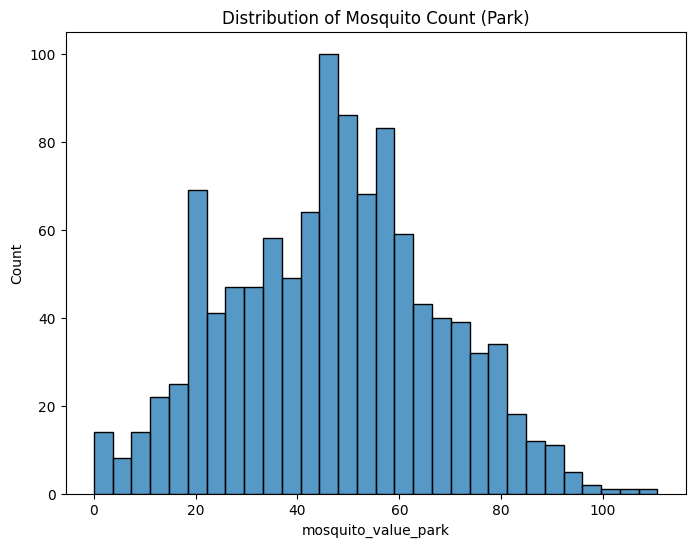

In [6]:
#타깃 변수 분포(공원부) , 이상치??
plt.figure(figsize=(8,6))
sns.histplot(df["mosquito_value_park"], bins=30)
plt.title("Distribution of Mosquito Count (Park)")
plt.show()

In [17]:
df["날짜"] = pd.to_datetime(df["날짜"])

df["year"] = df["날짜"].dt.year
df["month"] = df["날짜"].dt.month
df["day"] = df["날짜"].dt.day

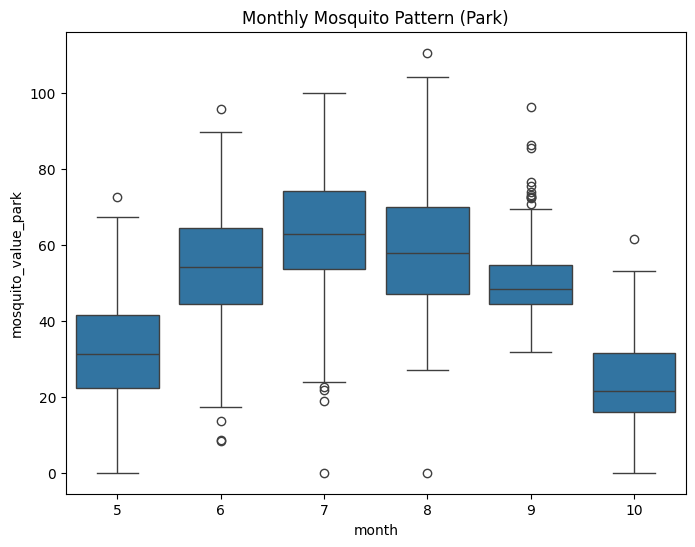

In [21]:
plt.figure(figsize=(8,6))

sns.boxplot(
    x="month",
    y="mosquito_value_park",
    data=df
)

plt.title("Monthly Mosquito Pattern (Park)")
plt.show()
#7월 peak
#10월 급감
#계절성 존재

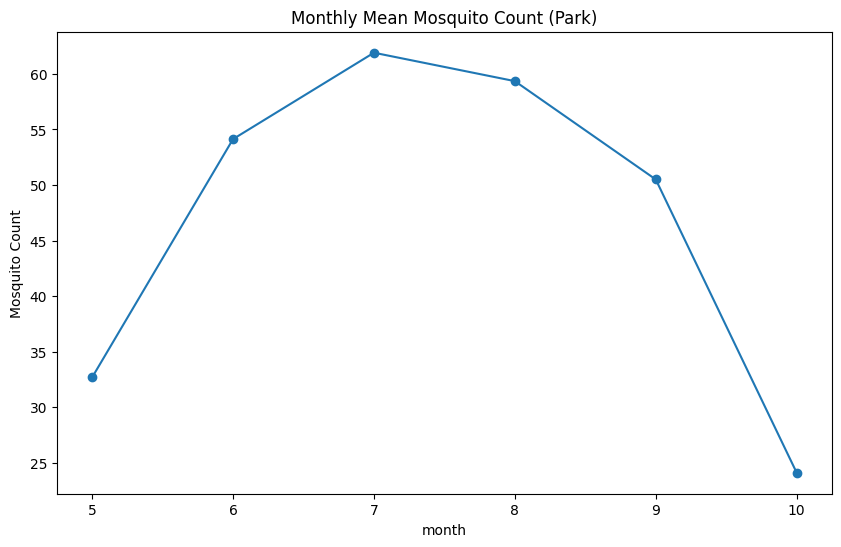

In [22]:
monthly_mean = df.groupby("month")["mosquito_value_park"].mean()

plt.figure(figsize=(10,6))
monthly_mean.plot(marker='o')

plt.title("Monthly Mean Mosquito Count (Park)")
plt.ylabel("Mosquito Count")
plt.show()
#5월 증가 시작
#7월 최고
#10월 감소

/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 52509 (\N{HANGUL SYLLABLE CONG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 51656 (\N{HANGUL SYLLABLE JIL}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 49548 (\N{HANGUL SYLLABLE SO}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 13198 (\N{SQUARE MG}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 50976 (\N{HANGUL SYLLABLE YU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.12/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/p

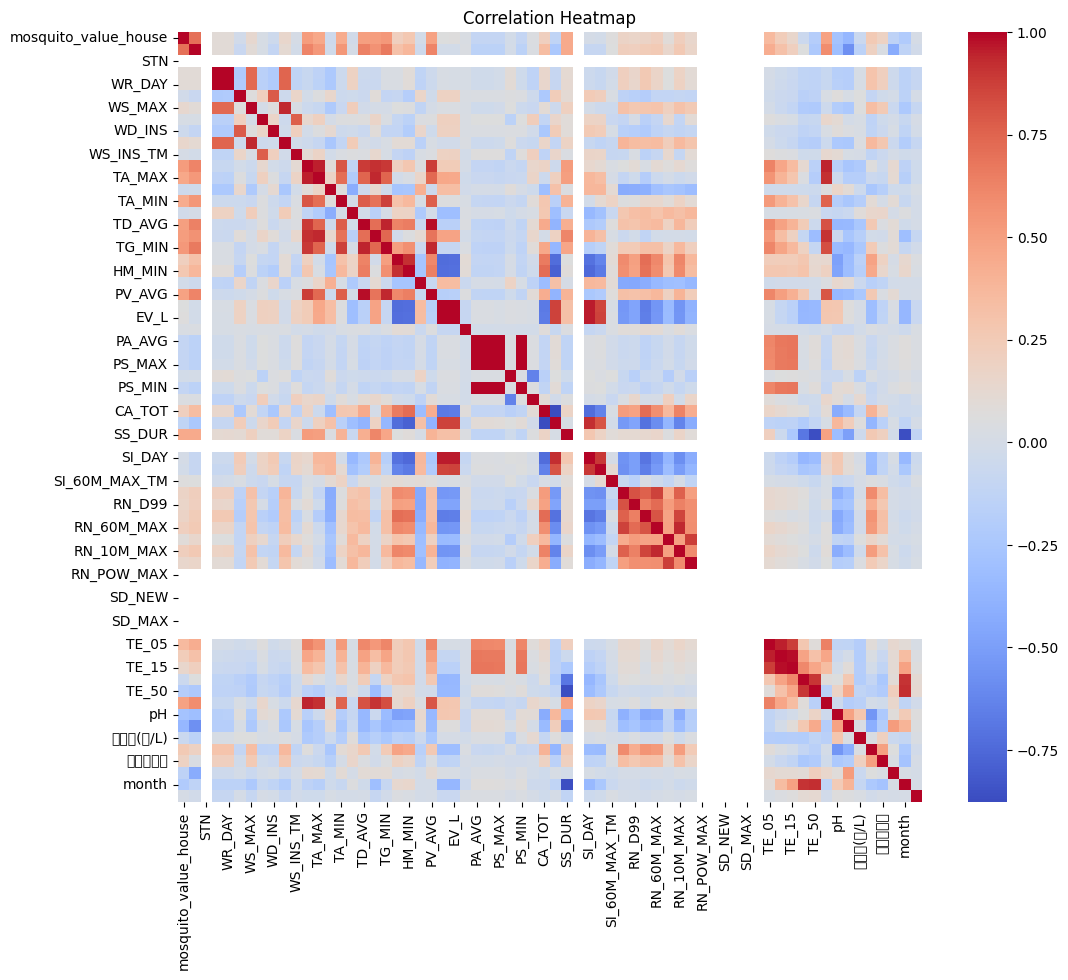

In [23]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()
#변수 줄여야 함

In [36]:
corr["mosquito_value_park"].sort_values(ascending=False).head(10)

# TA_AVG
# TA_MAX
# TA_MIN
# TG_MIN
# TD-AVG
# TS_AVG
# 수온
# PV_AVG

,mosquito_value_park
mosquito_value_park,1.000000
mosquito_value_house,0.700652
TG_MIN,0.662705
TD_AVG,0.639951
TA_AVG,0.625931
PV_AVG,0.623935
수온,0.585171
TS_AVG,0.566572
TA_MIN,0.542520
TA_MAX,0.535202


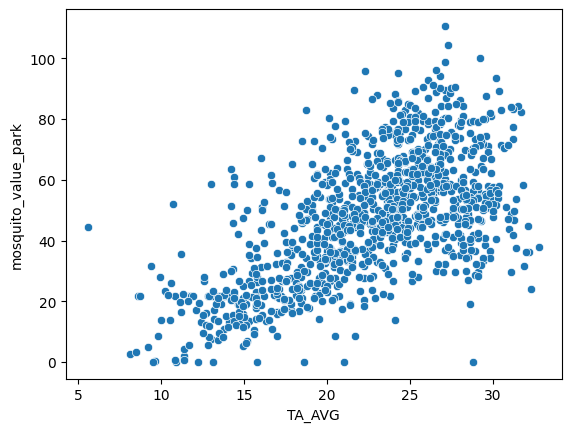

In [25]:
sns.scatterplot(
    x=df["TA_AVG"],
    y=df["mosquito_value_park"]
)

plt.show()

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50728 (\N{HANGUL SYLLABLE ON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


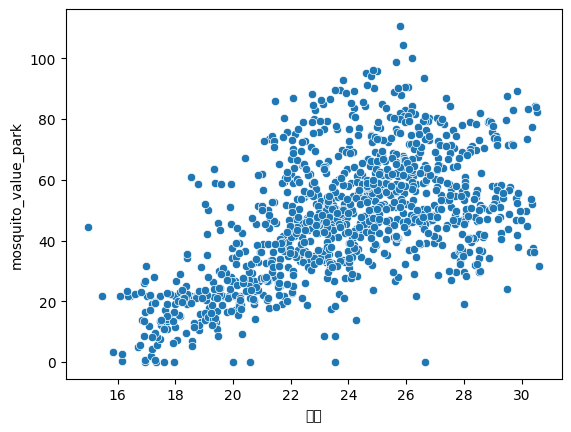

In [26]:
sns.scatterplot(
    x=df["수온"],
    y=df["mosquito_value_park"]
)

plt.show()
#수온과 기온이 높을수록 모기 발생률도 높아짐

In [27]:
corr["mosquito_value_park"].sort_values()

,mosquito_value_park
용존산소(㎎/L),-0.574309
year,-0.428569
pH,-0.305988
SS_DAY,-0.239854
TE_50,-0.225313
...,...
RN_POW_MAX_TM,NaN
SD_NEW,NaN
SD_NEW_TM,NaN
SD_MAX,NaN


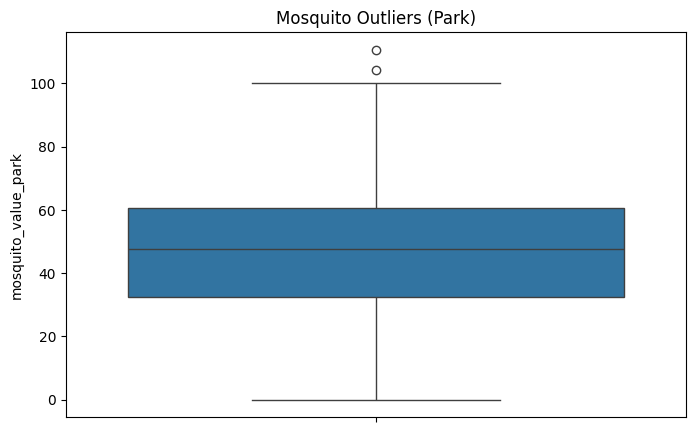

In [35]:
#이상치 확인
plt.figure(figsize=(8,5))

sns.boxplot(
    y=df["mosquito_value_park"]
)

plt.title("Mosquito Outliers (Park)")
plt.show()

<Axes: xlabel='mosquito_value_house', ylabel='Count'>

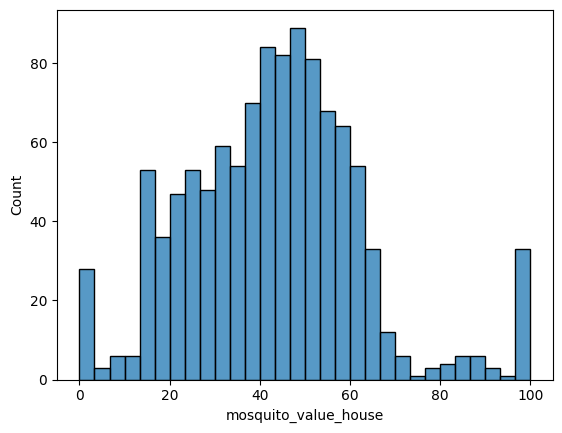

In [33]:
sns.histplot(df["mosquito_value_house"], bins=30)

<Axes: xlabel='날짜', ylabel='mosquito_value_house'>

/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/events.py:89: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45216 (\N{HANGUL SYLLABLE NAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51676 (\N{HANGUL SYLLABLE JJA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


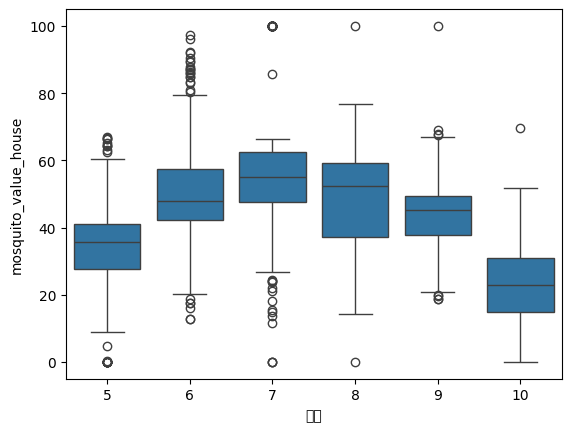

In [31]:
sns.boxplot(x=df["날짜"].dt.month,
            y=df["mosquito_value_house"])

<Axes: xlabel='TA_AVG', ylabel='mosquito_value_house'>

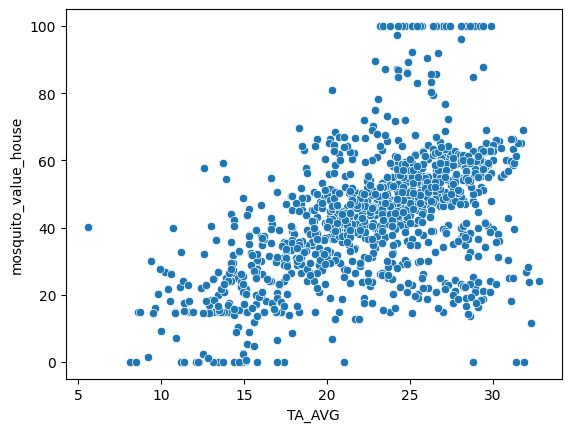

In [32]:
sns.scatterplot(x=df["TA_AVG"],
                y=df["mosquito_value_house"])